# 🔍 Visualisation — Crop & Padding centré

Comparaison des deux approches :
- **Approche A** : Crop bounding box (non carré) → Padding centré → Carré
- **Approche B** : Crop carré direct centré sur la bounding box

Pipeline complet visualisé étape par étape.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image

In [2]:
RAW_ROOT = Path("../data/raw/COVID-19_Radiography_Dataset")

# Quelques images de classes différentes pour voir la variabilité
SAMPLES = [
    (RAW_ROOT / "COVID"           / "images" / "COVID-1.png",           RAW_ROOT / "COVID"           / "masks" / "COVID-1.png"),
    (RAW_ROOT / "COVID"           / "images" / "COVID-10.png",          RAW_ROOT / "COVID"           / "masks" / "COVID-10.png"),
    (RAW_ROOT / "Normal"          / "images" / "Normal-1.png",          RAW_ROOT / "Normal"          / "masks" / "Normal-1.png"),
    (RAW_ROOT / "Lung_Opacity"    / "images" / "Lung_Opacity-1.png",    RAW_ROOT / "Lung_Opacity"    / "masks" / "Lung_Opacity-1.png"),
    (RAW_ROOT / "Viral Pneumonia" / "images" / "Viral Pneumonia-1.png", RAW_ROOT / "Viral Pneumonia" / "masks" / "Viral Pneumonia-1.png"),
]

In [3]:
def load_image_and_mask(img_path, mask_path):
    """Charge image (grayscale) + mask, resize mask → taille image."""
    img  = np.array(Image.open(img_path).convert('L'))   # (299, 299) uint8
    mask = np.array(Image.open(mask_path).convert('L'))  # (256, 256) uint8

    # Resize mask → taille image avec INTER_NEAREST (préserve les valeurs binaires)
    h, w = img.shape
    mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

    # S'assurer que le mask est bien 0/255
    mask_binary = (mask_resized > 127).astype(np.uint8) * 255

    return img, mask_binary


def apply_mask(img, mask_binary):
    """Masquage bitwise."""
    return cv2.bitwise_and(img, img, mask=mask_binary)


def get_union_bbox(mask_binary):
    """Bounding box union de TOUS les contours du mask (les deux poumons)."""
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    all_pts = np.concatenate(contours)  # union de tous les contours
    x, y, w, h = cv2.boundingRect(all_pts)
    return x, y, w, h


# ── Approche A : Crop serré + padding centré ──
def crop_with_centered_padding(masked_img, bbox):
    """Crop la bounding box puis la centre dans un carré avec padding noir."""
    x, y, w, h = bbox
    cropped = masked_img[y:y+h, x:x+w]

    side = max(w, h)
    padded = np.zeros((side, side), dtype=np.uint8)

    pad_top  = (side - h) // 2
    pad_left = (side - w) // 2
    padded[pad_top:pad_top+h, pad_left:pad_left+w] = cropped

    return cropped, padded


# ── Approche B : Crop carré direct centré ──
def crop_square_centered(masked_img, bbox):
    """Crop un carré centré sur la bounding box, sans padding."""
    x, y, w, h = bbox
    side = max(w, h)
    cx, cy = x + w // 2, y + h // 2

    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(masked_img.shape[1], x1 + side)
    y2 = min(masked_img.shape[0], y1 + side)

    # Réajuster si on a clampé sur un bord
    x1 = max(0, x2 - side)
    y1 = max(0, y2 - side)

    return masked_img[y1:y2, x1:x2], (x1, y1, x2, y2)


print("Fonctions chargées.")

Fonctions chargées.


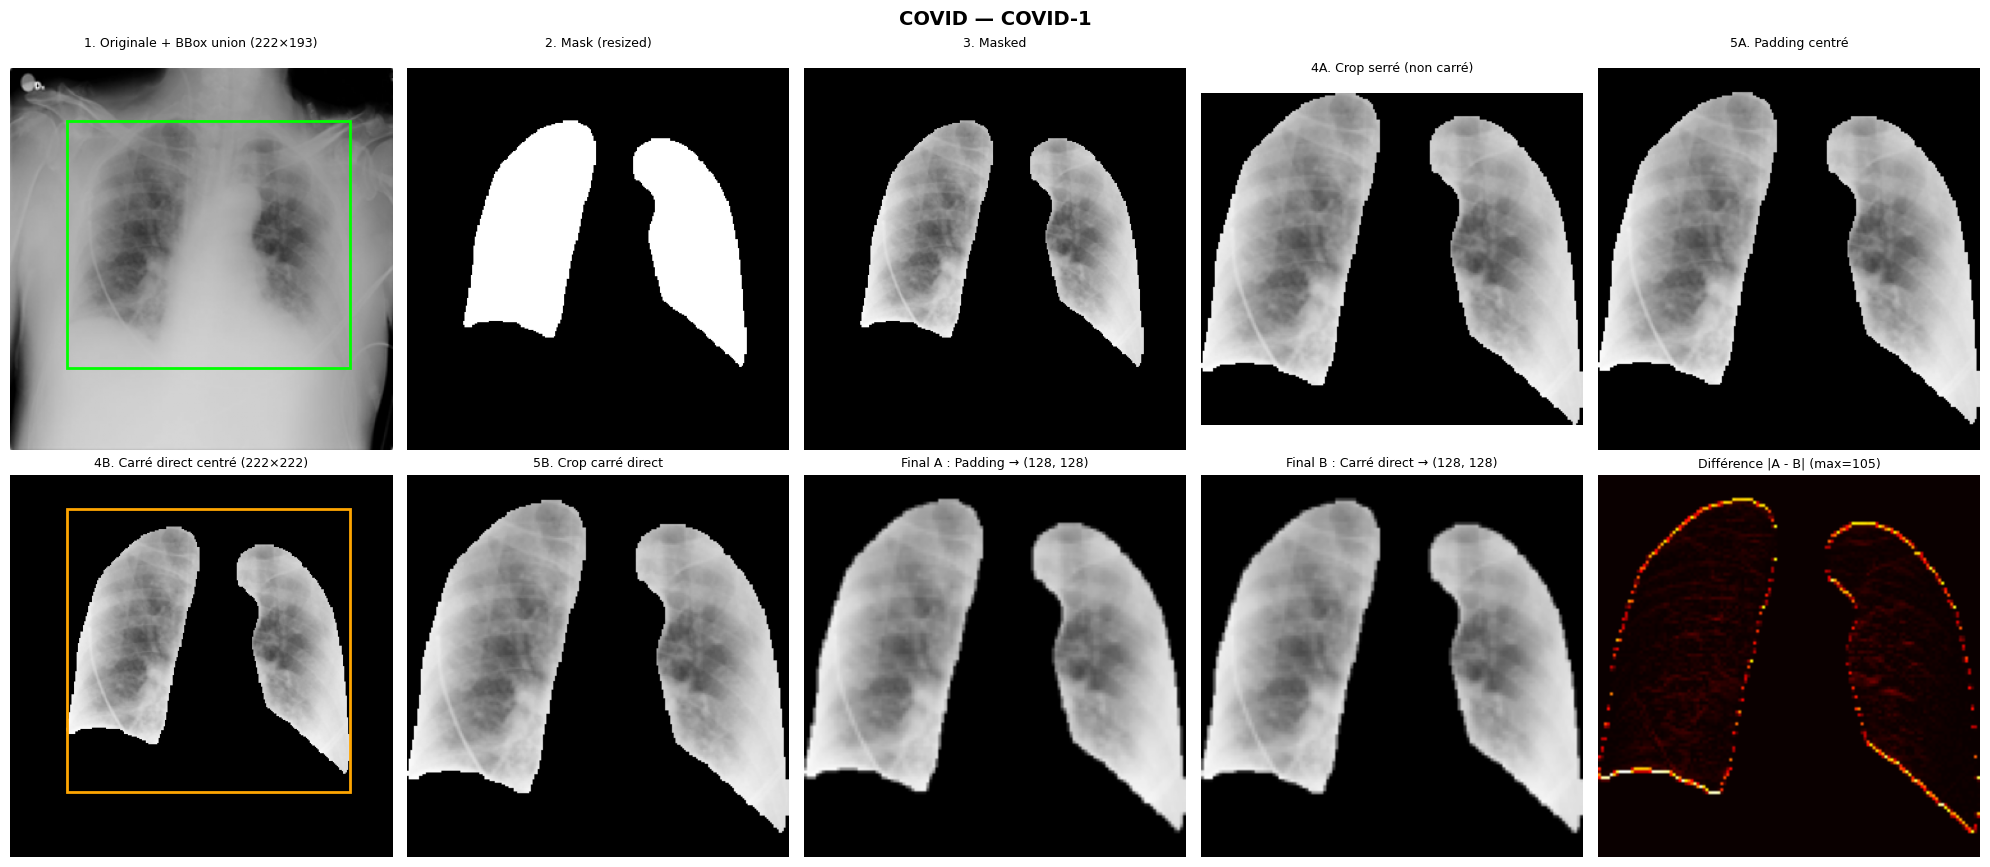

  BBox union : x=44 y=41 w=222 h=193 | Carré : 222×222



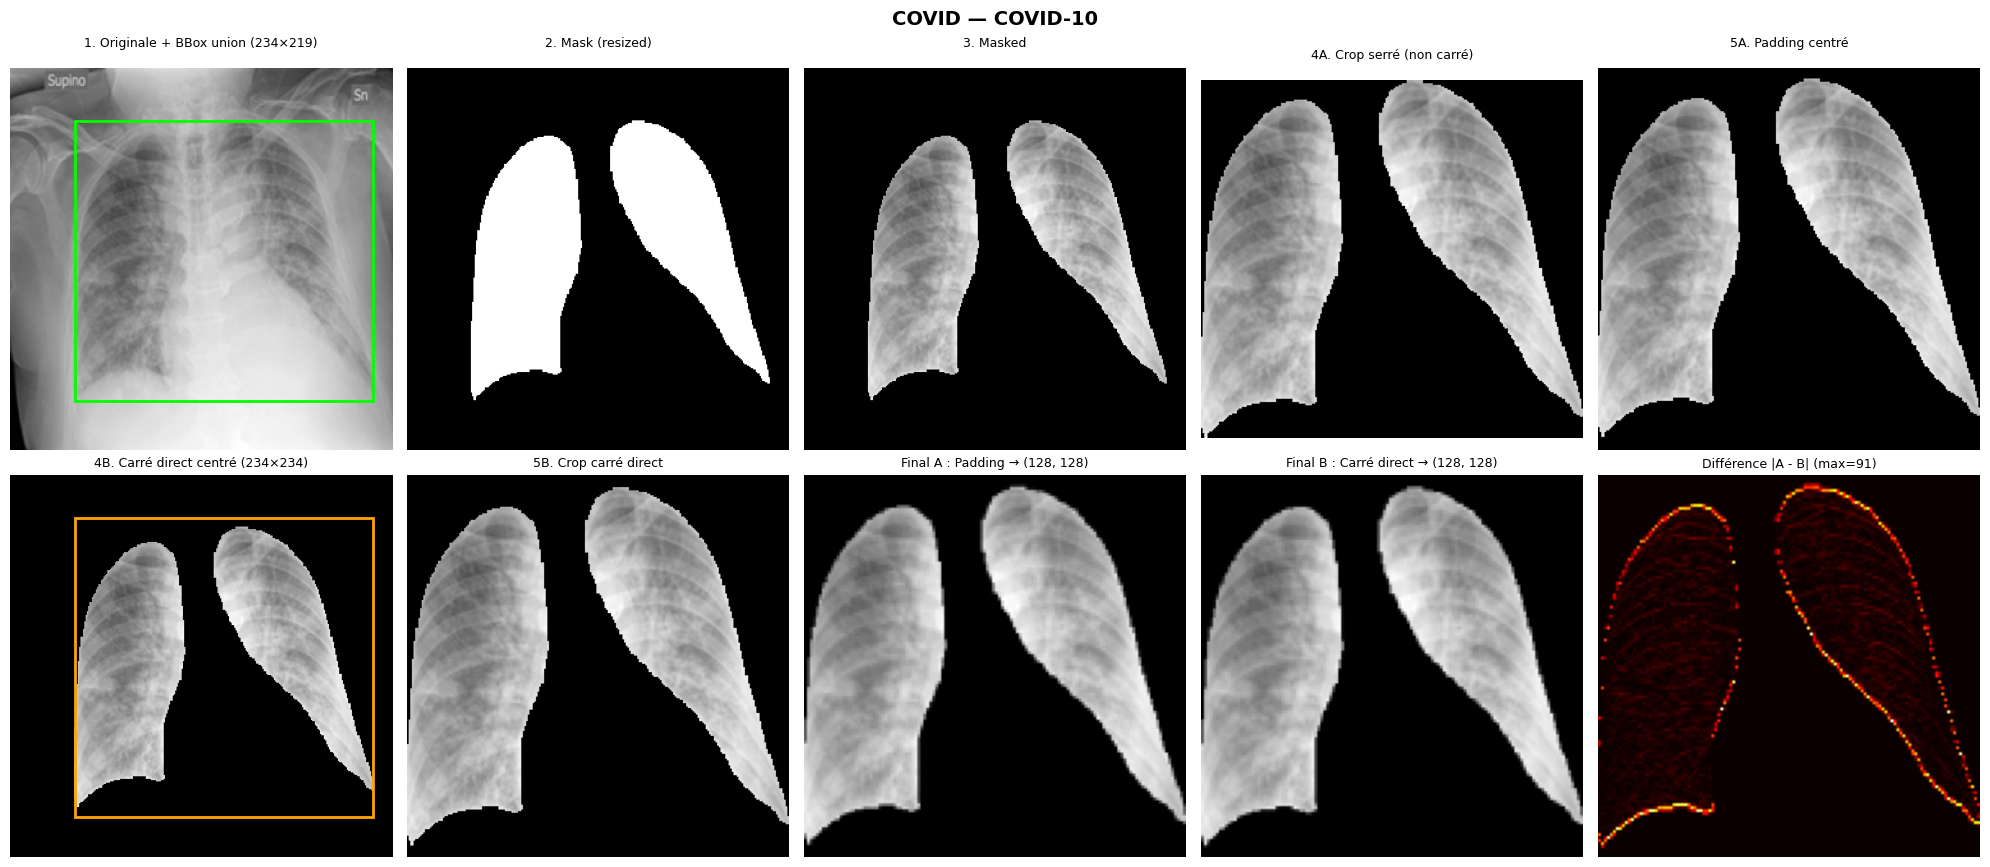

  BBox union : x=50 y=41 w=234 h=219 | Carré : 234×234



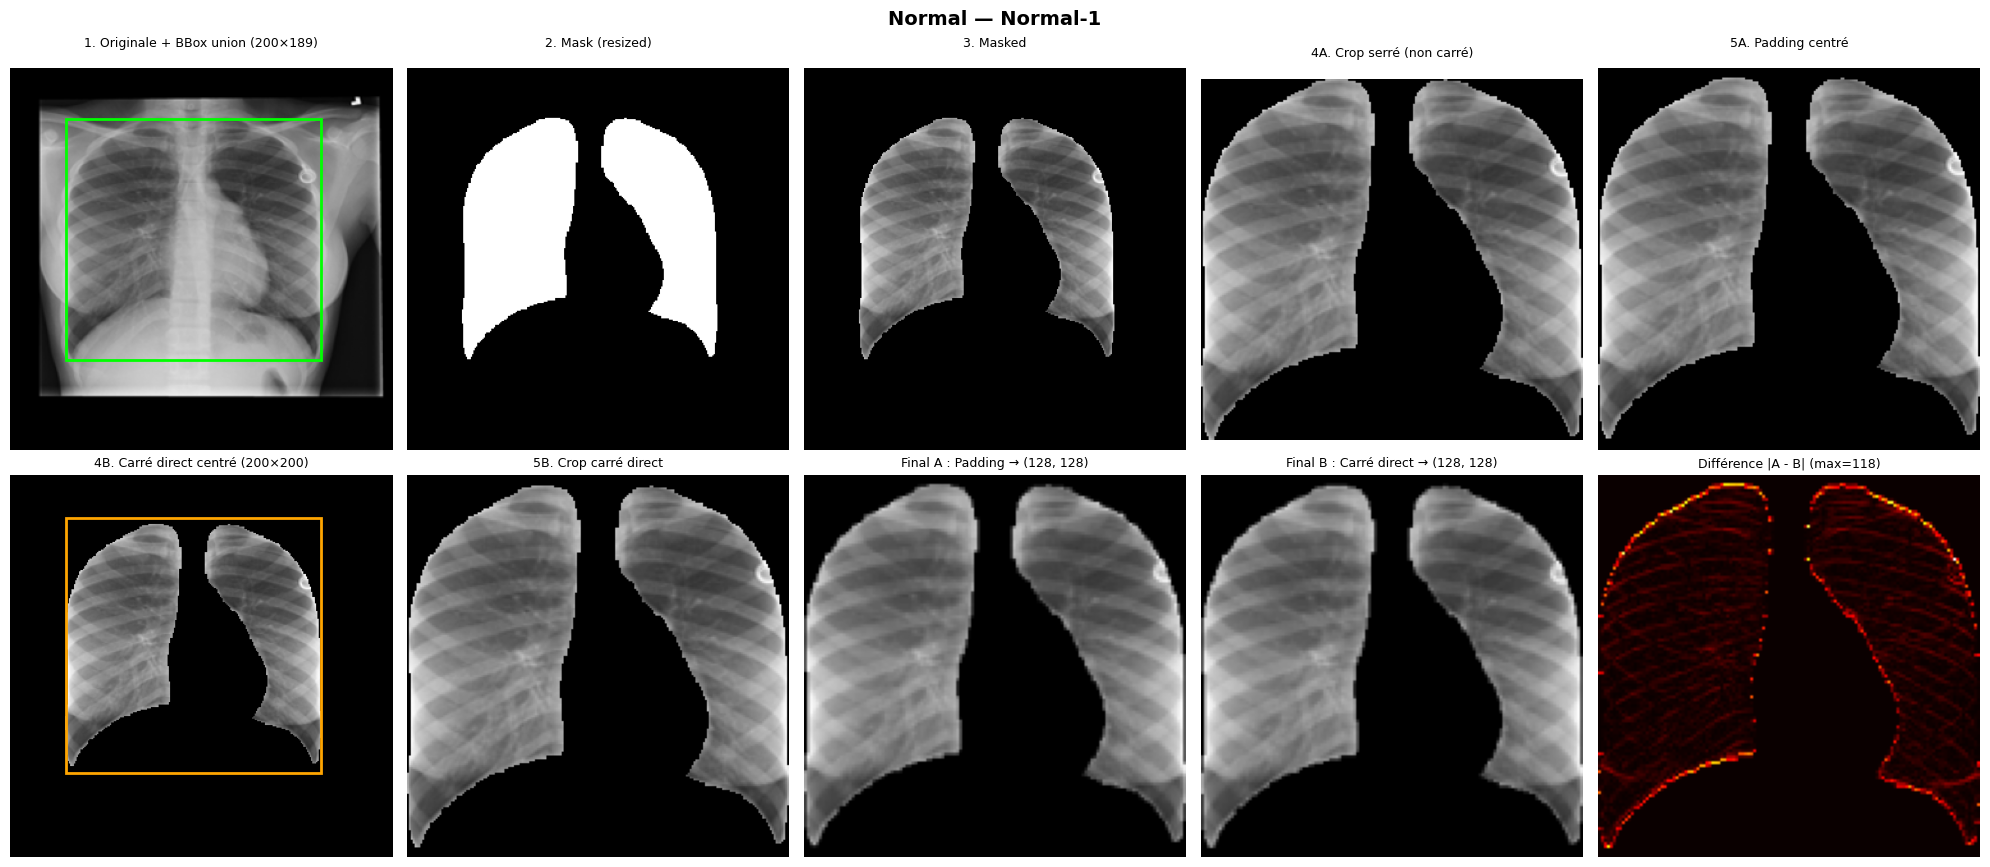

  BBox union : x=43 y=39 w=200 h=189 | Carré : 200×200



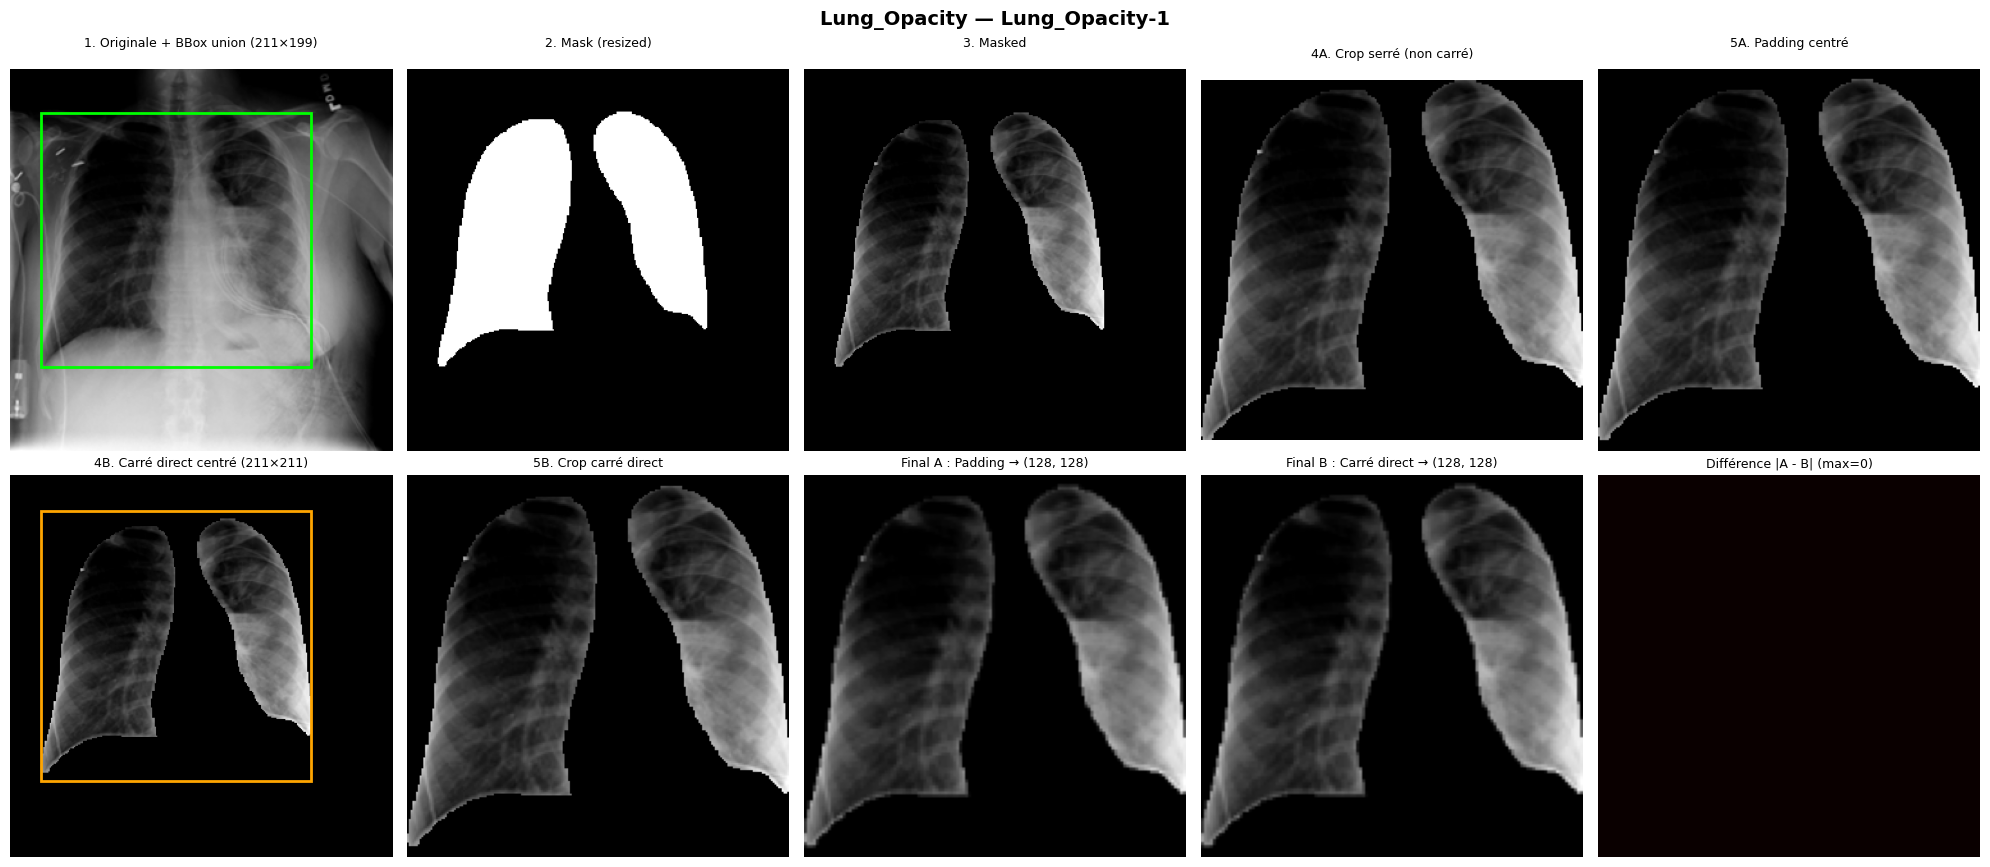

  BBox union : x=24 y=34 w=211 h=199 | Carré : 211×211



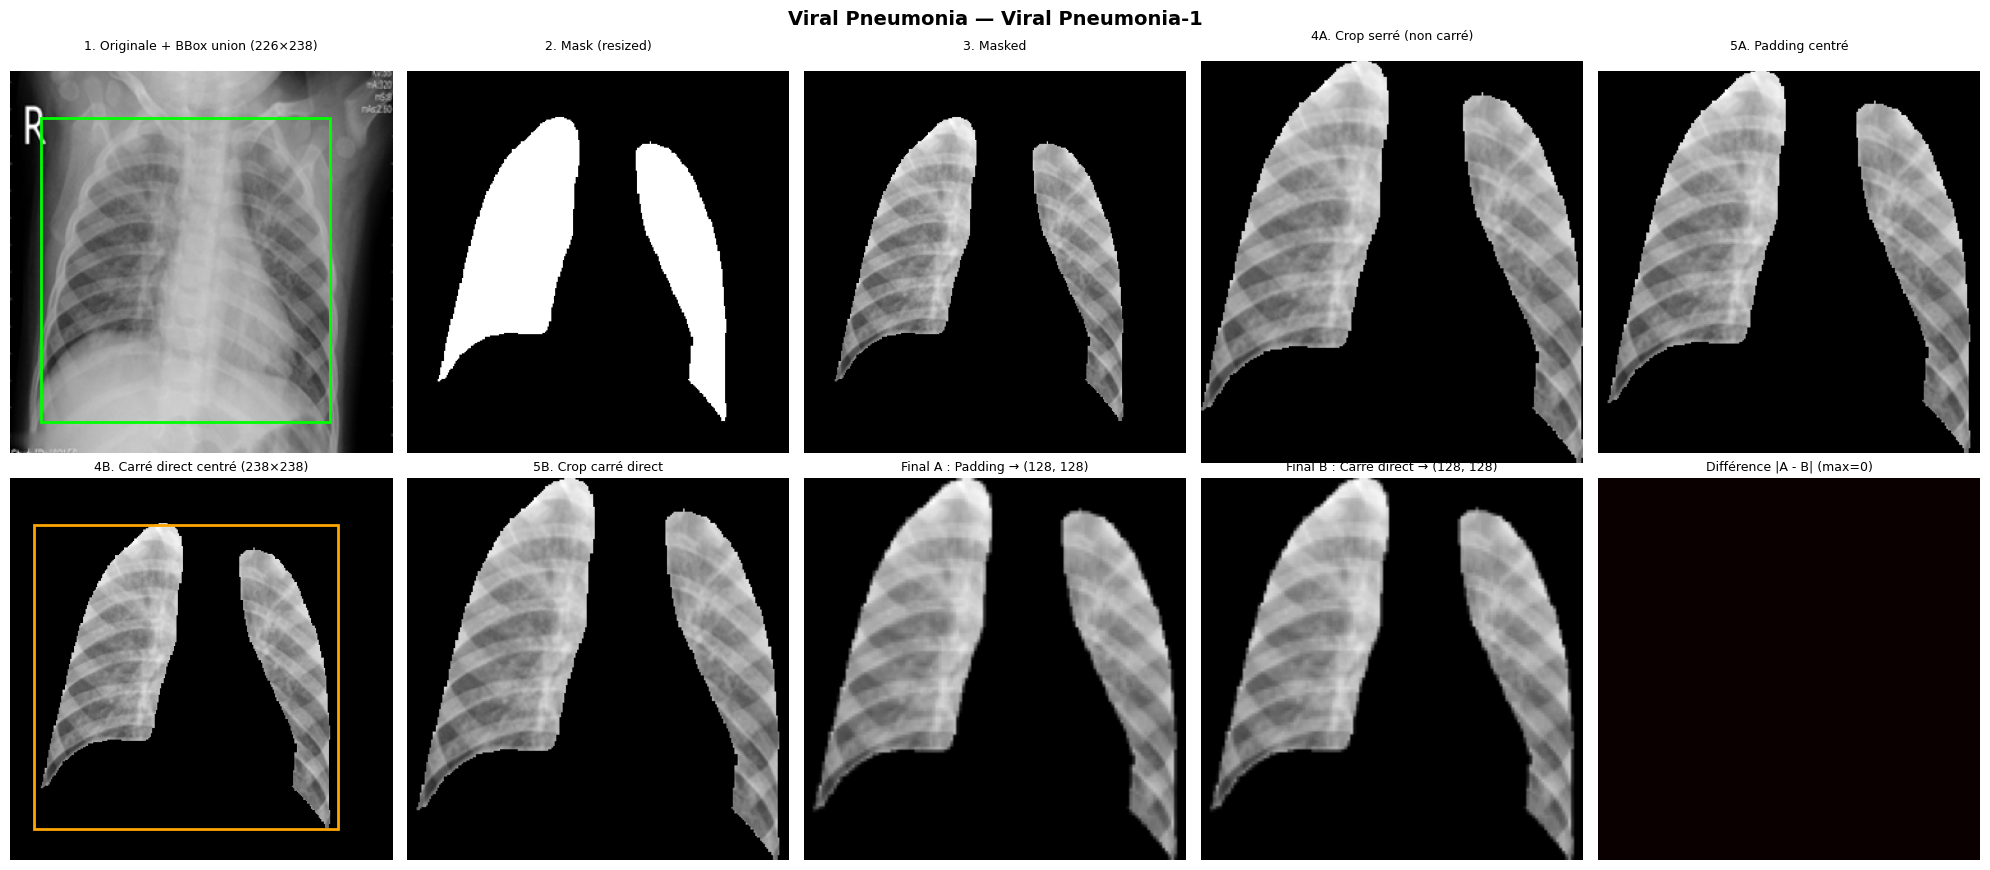

  BBox union : x=24 y=36 w=226 h=238 | Carré : 238×238



In [4]:
TARGET_SIZE = (128, 128)

for img_path, mask_path in SAMPLES:
    label = img_path.parent.parent.name  # nom de la classe
    name  = img_path.stem

    # ── Pipeline ──
    img, mask_binary = load_image_and_mask(img_path, mask_path)
    masked = apply_mask(img, mask_binary)
    bbox   = get_union_bbox(mask_binary)

    if bbox is None:
        print(f"[{name}] Aucun contour trouvé — image ignorée")
        continue

    x, y, w, h = bbox
    cropped_tight, padded_centered = crop_with_centered_padding(masked, bbox)
    square_direct, sq_coords       = crop_square_centered(masked, bbox)

    # Resize final
    padded_resized = cv2.resize(padded_centered, TARGET_SIZE, interpolation=cv2.INTER_AREA)
    square_resized = cv2.resize(square_direct,   TARGET_SIZE, interpolation=cv2.INTER_AREA)

    # ── Figure ──
    fig, axes = plt.subplots(2, 5, figsize=(20, 9))
    fig.suptitle(f"{label} — {name}", fontsize=14, fontweight='bold')

    # Ligne 1 : étapes du pipeline
    titles_top = ["1. Image originale", "2. Mask (resized)", "3. Masked",
                  "4A. Crop serré (non carré)", "5A. Padding centré"]
    images_top = [img, mask_binary, masked, cropped_tight, padded_centered]

    for ax, title, im in zip(axes[0], titles_top, images_top):
        ax.imshow(im, cmap='gray')
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        # Afficher la taille
        ax.set_xlabel(f"{im.shape[1]}×{im.shape[0]}", fontsize=8)
        ax.xaxis.set_label_position('top')

    # Bounding box sur l'image originale
    rect = patches.Rectangle((x, y), w, h, linewidth=2,
                               edgecolor='lime', facecolor='none')
    axes[0, 0].add_patch(rect)
    axes[0, 0].set_title(f"1. Originale + BBox union ({w}×{h})", fontsize=9)

    # Ligne 2 : approche B + comparaison finale
    x1, y1, x2, y2 = sq_coords
    sq_rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2,
                                  edgecolor='orange', facecolor='none')

    axes[1, 0].imshow(masked, cmap='gray')
    axes[1, 0].add_patch(sq_rect)
    axes[1, 0].set_title(f"4B. Carré direct centré ({x2-x1}×{y2-y1})", fontsize=9)
    axes[1, 0].axis('off')

    axes[1, 1].imshow(square_direct, cmap='gray')
    axes[1, 1].set_title("5B. Crop carré direct", fontsize=9)
    axes[1, 1].axis('off')

    axes[1, 2].imshow(padded_resized, cmap='gray')
    axes[1, 2].set_title(f"Final A : Padding → {TARGET_SIZE}", fontsize=9)
    axes[1, 2].axis('off')

    axes[1, 3].imshow(square_resized, cmap='gray')
    axes[1, 3].set_title(f"Final B : Carré direct → {TARGET_SIZE}", fontsize=9)
    axes[1, 3].axis('off')

    # Différence absolue entre les deux finaux
    diff = np.abs(padded_resized.astype(int) - square_resized.astype(int)).astype(np.uint8)
    axes[1, 4].imshow(diff, cmap='hot')
    axes[1, 4].set_title(f"Différence |A - B| (max={diff.max()})", fontsize=9)
    axes[1, 4].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"  BBox union : x={x} y={y} w={w} h={h} | Carré : {max(w,h)}×{max(w,h)}")
    print()

In [ ]:
def crop_to_lungs(masked_img: np.ndarray, mask_binary: np.ndarray) -> np.ndarray:
    """
    Crop un carré centré sur la bounding box union des deux poumons.
    
    Args:
        masked_img  : image après masking, uint8 2D (grayscale)
        mask_binary : mask binaire 0/255, uint8 2D, même taille que masked_img
    
    Returns:
        Image croppée carrée, uint8 2D. Si aucun contour trouvé, retourne masked_img inchangée.
    """
    contours, _ = cv2.findContours(mask_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # contour est une liste de tableaux de points (un tableau par contour).
    
    if not contours:
        return masked_img
    
    # Bounding box union des deux poumons
    x, y, w, h = cv2.boundingRect(np.concatenate(contours))
    
    # Carré centré sur la bounding box
    side = max(w, h)
    cx   = x + w // 2
    cy   = y + h // 2
    
    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(masked_img.shape[1], x1 + side)
    y2 = min(masked_img.shape[0], y1 + side)
    
    # Réajuster si clampé sur un bord
    x1 = max(0, x2 - side)
    y1 = max(0, y2 - side)
    
    return masked_img[y1:y2, x1:x2]

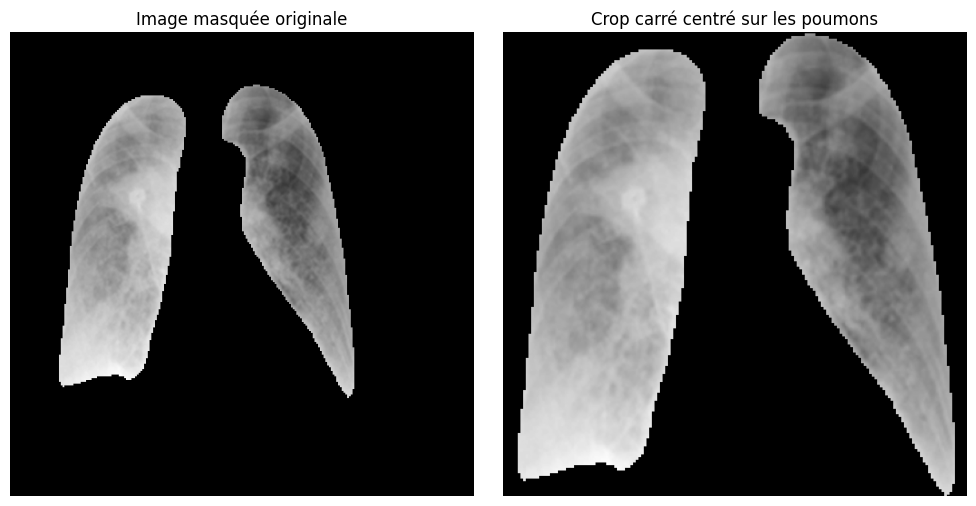

In [13]:
masked_img_path = "/home/cepa/DST/DS_COVID/data/processed/masked_full_dataset_512_512_L/Lung_Opacity/Lung_Opacity-5600.png"

masked_img = cv2.imread(masked_img_path, cv2.IMREAD_GRAYSCALE)

cropped = squared_crop_to_lungs(masked_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(masked_img, cmap='gray')
plt.title("Image masquée originale")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped, cmap='gray')
plt.title("Crop carré centré sur les poumons")
plt.axis('off')
plt.tight_layout()
plt.show()